# First Visit Model — IUI Pregnancy Prediction

**Pre-procedural model** ใช้เฉพาะข้อมูลที่รู้ก่อนเริ่ม IUI

Pipeline:
1. Load data
2. Train/test split (same seed as full model)
3. Feature preparation + imputation
4. Hyperparameter search (RandomizedSearchCV)
5. Isotonic calibration (group-aware)
6. Evaluate on test set
7. Bootstrap CI (n=1000)
8. Risk tiers
9. Comparison table vs Full Model
10. Save models + tables

In [1]:
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, RandomizedSearchCV
)
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, confusion_matrix
)
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
print("✅ Imports OK")

✅ Imports OK


In [2]:
# ปรับ PROJECT_ROOT ถ้าจำเป็น
# notebook นี้ควรอยู่ใน src/ หรือ notebooks/
PROJECT_ROOT = Path.cwd().parent

DATA_PATH  = PROJECT_ROOT / "data" / "processed" / "cycle_level_features.csv"
MODEL_DIR  = PROJECT_ROOT / "models" / "saved_models" / "first_visit_model"
REPORT_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "first_visit_model"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Full model reference (จาก bootstrap ที่รันไปแล้ว — อัพเดตถ้าตัวเลขเปลี่ยน)
FULL_MODEL_RESULTS = {
    "ROC_AUC":     "0.663 (0.570–0.742)",
    "PR_AUC":      "0.162 (0.089–0.265)",
    "Brier":       "0.063 (0.046–0.080)",
    "Sensitivity": "0.611",
    "Specificity": "0.629",
    "NPV":         "0.956",
    "PPV":         "0.109",
}

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH exists: {DATA_PATH.exists()}")

PROJECT_ROOT: e:\Ph D\Research\iui_ml_prediction
DATA_PATH exists: True


In [3]:
FIRST_VISIT_FEATURES = [
    # Female factors
    "Age_Female",
    "Body_Mass_Index",
    "Infertility_Type",
    "Total_infertile_duration",
    "Menstrual_Interval_Days",
    # Female pathology
    "Uterine_Factors",
    "Ovulatory_Factors",
    "Tubal_Factors",
    "Endometriosis_Factors",
    "Gynecological_Surgical_History",
    "Total_Female_Pathology",
    # Sperm (first visit / prewash)
    "First_Volume",
    "First_Count",
    "First_Progressive_Motile",
    "First_TPMSC",
    # Engineered
    "BMI_InfertilityType_Interaction",
]

print(f"First visit features: {len(FIRST_VISIT_FEATURES)}")

First visit features: 16


## 1. Load Data

In [4]:
df = pd.read_csv(DATA_PATH)
df.columns = [re.sub(r"[\[\]<>]", "_", str(c)).replace(" ", "_") for c in df.columns]
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df["Result"] = pd.to_numeric(df["Result"], errors="coerce")
df = df.dropna(subset=["Result"])
df["Result"] = df["Result"].astype(int)
df["HN"] = df["HN"].astype(str).str.strip()
df = df[df["HN"] != ""]

print(f"Dataset:    {df.shape[0]} cycles, {df['HN'].nunique()} patients")
print(f"Event rate: {df['Result'].mean():.4f} ({int(df['Result'].sum())} pregnancies)")

Dataset:    2945 cycles, 1761 patients
Event rate: 0.0621 (183 pregnancies)


## 2. Train/Test Split (same seed as full model)

In [5]:
groups = df["HN"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, df["Result"], groups=groups))

df_train = df.iloc[train_idx].copy()
df_test  = df.iloc[test_idx].copy()

y_train      = df_train["Result"].values
y_test       = df_test["Result"].values
groups_train = df_train["HN"].values

assert len(set(df_train["HN"]) & set(df_test["HN"])) == 0, "Patient leakage!"

print(f"Train: {len(df_train)} cycles | Test: {len(df_test)} cycles")
print(f"Train positives: {y_train.sum()} ({y_train.mean():.4f})")
print(f"Test positives:  {y_test.sum()} ({y_test.mean():.4f})")
print("✅ No patient overlap")

Train: 2348 cycles | Test: 597 cycles
Train positives: 142 (0.0605)
Test positives:  41 (0.0687)
✅ No patient overlap


## 3. Feature Preparation

In [6]:
available_fv = [f for f in FIRST_VISIT_FEATURES if f in df.columns]
missing_fv   = [f for f in FIRST_VISIT_FEATURES if f not in df.columns]

if missing_fv:
    print(f"⚠️  Not found (skipped): {missing_fv}")

X_train_fv = df_train[available_fv].copy()
X_test_fv  = df_test[available_fv].copy()

imputer    = SimpleImputer(strategy="median")
X_train_fv = pd.DataFrame(imputer.fit_transform(X_train_fv), columns=available_fv)
X_test_fv  = pd.DataFrame(imputer.transform(X_test_fv),      columns=available_fv)

print(f"Using {len(available_fv)} features:")
for f in available_fv:
    print(f"  - {f}")

Using 16 features:
  - Age_Female
  - Body_Mass_Index
  - Infertility_Type
  - Total_infertile_duration
  - Menstrual_Interval_Days
  - Uterine_Factors
  - Ovulatory_Factors
  - Tubal_Factors
  - Endometriosis_Factors
  - Gynecological_Surgical_History
  - Total_Female_Pathology
  - First_Volume
  - First_Count
  - First_Progressive_Motile
  - First_TPMSC
  - BMI_InfertilityType_Interaction


## 4. Hyperparameter Search

In [7]:
pos_weight = float((len(y_train) - y_train.sum()) / max(y_train.sum(), 1))
group_cv   = GroupKFold(n_splits=3)

param_dist = {
    "model__n_estimators":     [100, 200, 300],
    "model__learning_rate":    [0.005, 0.01, 0.05, 0.1],
    "model__max_depth":        [2, 3, 4, 5],
    "model__subsample":        [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

pipeline = ImbPipeline([
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=pos_weight,
    ))
])

rs = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=group_cv,
    scoring="average_precision",
    random_state=42,
    n_jobs=-1,
    refit=True,
)
rs.fit(X_train_fv, y_train, groups=groups_train)

clean_params = {k.replace("model__", ""): v for k, v in rs.best_params_.items()}

print(f"Best PR-AUC (CV): {rs.best_score_:.4f}")
print(f"Best params: {rs.best_params_}")

Best PR-AUC (CV): 0.1556
Best params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.005, 'model__colsample_bytree': 1.0}


### Calibration plot

In [13]:
# FIX: Stratified group-aware calibration split (40%)
unique_patients = (pd.DataFrame({"HN": groups_train, "y": y_train})
                   .drop_duplicates("HN").set_index("HN")["y"])
pos_patients = unique_patients[unique_patients == 1].index.tolist()
neg_patients = unique_patients[unique_patients == 0].index.tolist()

rng = np.random.RandomState(42)
rng.shuffle(pos_patients)
rng.shuffle(neg_patients)

n_pos_cal = max(1, int(len(pos_patients) * 0.40))
n_neg_cal = max(1, int(len(neg_patients) * 0.40))
cal_patients = set(pos_patients[:n_pos_cal]) | set(neg_patients[:n_neg_cal])

cal_mask      = pd.Series(groups_train).isin(cal_patients).values
subtrain_mask = ~cal_mask

subtrain_idx = np.where(subtrain_mask)[0]
cal_idx      = np.where(cal_mask)[0]

X_subtrain = X_train_fv.iloc[subtrain_idx]
y_subtrain = pd.Series(y_train).iloc[subtrain_idx]
X_cal      = X_train_fv.iloc[cal_idx]
y_cal      = pd.Series(y_train).iloc[cal_idx]

groups_sub   = pd.Series(groups_train).iloc[subtrain_idx]
groups_cal_s = pd.Series(groups_train).iloc[cal_idx]
assert len(set(groups_sub) & set(groups_cal_s)) == 0, "Calibration leakage!"

print(f"Subtrain: {len(X_subtrain)} | positives: {int(y_subtrain.sum())} ({y_subtrain.mean():.1%})")
print(f"Cal set:  {len(X_cal)} | positives: {int(y_cal.sum())} ({y_cal.mean():.1%})")
print(f"Full train event rate: {y_train.mean():.1%}")

pos_weight_sub = float(
    (len(y_subtrain) - y_subtrain.sum()) / max(y_subtrain.sum(), 1)
)

xgb_fv_cal = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=pos_weight_sub,
    **clean_params,
)
xgb_fv_cal.fit(X_subtrain, y_subtrain)

cal_probs_raw = xgb_fv_cal.predict_proba(X_cal)[:, 1]
iso_fv = IsotonicRegression(out_of_bounds="clip")
iso_fv.fit(cal_probs_raw, y_cal)

# FIX: Threshold จาก calibrated probs บน cal set
cal_probs_calibrated = np.clip(iso_fv.predict(cal_probs_raw), 0, 1)
fpr_cal, tpr_cal, thresholds_cal = roc_curve(y_cal, cal_probs_calibrated)
THRESHOLD_FV = float(thresholds_cal[(tpr_cal - fpr_cal).argmax()])
print(f"\nThreshold (from cal set Youden): {THRESHOLD_FV:.6f}")

# Save threshold
pd.DataFrame([{"threshold": THRESHOLD_FV, "source": "cal_set_youden_isotonic_40pct"}]).to_excel(
    REPORT_DIR / "fv_calibration_threshold.xlsx", index=False
)
print("✅ Calibration done")

Subtrain: 1403 | positives: 80 (5.7%)
Cal set:  945 | positives: 62 (6.6%)
Full train event rate: 6.0%

Threshold (from cal set Youden): 0.098507
✅ Calibration done


In [14]:
import matplotlib
matplotlib.use('Agg')
from sklearn.calibration import calibration_curve
from IPython.display import display, Image as IPImage

test_probs_raw_fv = xgb_fv_cal.predict_proba(X_test_fv)[:, 1]
test_probs_cal_fv = np.clip(iso_fv.predict(test_probs_raw_fv), 0, 1)

brier_before_fv = brier_score_loss(np.array(y_test), test_probs_raw_fv)
brier_after_fv  = brier_score_loss(np.array(y_test), test_probs_cal_fv)

prob_true_before, prob_pred_before = calibration_curve(
    y_test, test_probs_raw_fv, n_bins=6, strategy="quantile")
prob_true_after, prob_pred_after = calibration_curve(
    y_test, test_probs_cal_fv, n_bins=6, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6), facecolor='white')
ax.set_facecolor('white')
ax.plot(prob_pred_before, prob_true_before, marker='o', linewidth=2,
        label=f'Before calibration (Brier={brier_before_fv:.4f})')
ax.plot(prob_pred_after, prob_true_after, marker='s', linewidth=2,
        label=f'After calibration (Brier={brier_after_fv:.4f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray',
        label='Perfect calibration')
ax.set_xlabel('Predicted probability', fontsize=13)
ax.set_ylabel('Observed probability', fontsize=13)
ax.set_title('Calibration Curve — First Visit Model', fontsize=14, pad=12)
ax.legend(frameon=False, fontsize=11)
ax.grid(alpha=0.18)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "Calibration_Plot_FirstVisit.png",
            dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print(f"Brier before: {brier_before_fv:.4f} → after: {brier_after_fv:.4f}")

Brier before: 0.1992 → after: 0.0632


## 6. Evaluate on Test Set

In [15]:
test_probs_raw_fv = xgb_fv_cal.predict_proba(X_test_fv)[:, 1]
test_probs_cal_fv = np.clip(iso_fv.predict(test_probs_raw_fv), 0, 1)

# ROC-AUC, PR-AUC → raw
roc_fv   = roc_auc_score(y_test, test_probs_raw_fv)
pr_fv    = average_precision_score(y_test, test_probs_raw_fv)
brier_fv = brier_score_loss(y_test, test_probs_cal_fv)

# FIX: ใช้ THRESHOLD_FV จาก cal set ที่ save ไว้แล้ว
best_thresh = THRESHOLD_FV
y_pred = (test_probs_cal_fv >= best_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sens = tp / (tp + fn)
spec = tn / (tn + fp)
npv  = tn / (tn + fn)
ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0

print("=" * 50)
print("=== First Visit Model (pre-procedural) ===")
print("=" * 50)
print(f"Features:    {len(available_fv)}")
print(f"Threshold:   {best_thresh:.6f}  (Youden, cal set ✅)")
print(f"ROC-AUC:     {roc_fv:.4f}  ← raw")
print(f"PR-AUC:      {pr_fv:.4f}  ← raw")
print(f"Brier (cal): {brier_fv:.4f}  ← calibrated")
print(f"Sensitivity: {sens:.4f} ({sens*100:.1f}%)")
print(f"Specificity: {spec:.4f} ({spec*100:.1f}%)")
print(f"NPV:         {npv:.4f} ({npv*100:.1f}%)")
print(f"PPV:         {ppv:.4f} ({ppv*100:.1f}%)")
print(f"TP={tp} FP={fp} TN={tn} FN={fn}")

=== First Visit Model (pre-procedural) ===
Features:    16
Threshold:   0.098507  (Youden, cal set ✅)
ROC-AUC:     0.6250  ← raw
PR-AUC:      0.1039  ← raw
Brier (cal): 0.0632  ← calibrated
Sensitivity: 0.6585 (65.9%)
Specificity: 0.5791 (57.9%)
NPV:         0.9583 (95.8%)
PPV:         0.1034 (10.3%)
TP=27 FP=234 TN=322 FN=14


## 7. Bootstrap CI (n=1000)

In [16]:
np.random.seed(42)
n_bootstrap = 1000

# FIX: โหลด threshold จาก cal set ไม่ใช่ test set
threshold_df = pd.read_excel(REPORT_DIR / "fv_calibration_threshold.xlsx")
THRESHOLD_FV = float(threshold_df["threshold"].iloc[0])
print(f"Threshold (from cal set): {THRESHOLD_FV:.6f}")

boot = {k: [] for k in ["ROC_AUC", "PR_AUC", "Brier",
                          "Sensitivity", "Specificity", "NPV", "PPV"]}

y_arr = np.array(y_test)
p_raw = np.array(test_probs_raw_fv)
p_cal = np.array(test_probs_cal_fv)

for _ in range(n_bootstrap):
    idx  = np.random.choice(len(y_arr), size=len(y_arr), replace=True)
    y_b  = y_arr[idx]
    pr_b = p_raw[idx]
    pc_b = p_cal[idx]

    if len(np.unique(y_b)) < 2:
        continue
    try:
        boot["ROC_AUC"].append(roc_auc_score(y_b, pr_b))
        boot["PR_AUC"].append(average_precision_score(y_b, pr_b))
        boot["Brier"].append(brier_score_loss(y_b, pc_b))

        y_pred_b = (pc_b >= THRESHOLD_FV).astype(int)
        tn_b, fp_b, fn_b, tp_b = confusion_matrix(
            y_b, y_pred_b, labels=[0, 1]
        ).ravel()
        boot["Sensitivity"].append(tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else np.nan)
        boot["Specificity"].append(tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan)
        boot["NPV"].append(tn_b / (tn_b + fn_b) if (tn_b + fn_b) > 0 else np.nan)
        boot["PPV"].append(tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else np.nan)
    except Exception:
        continue

y_pred_point = (p_cal >= THRESHOLD_FV).astype(int)
tn_p, fp_p, fn_p, tp_p = confusion_matrix(y_arr, y_pred_point, labels=[0, 1]).ravel()

point_est = {
    "ROC_AUC":     roc_fv,
    "PR_AUC":      pr_fv,
    "Brier":       brier_fv,
    "Sensitivity": tp_p / (tp_p + fn_p),
    "Specificity": tn_p / (tn_p + fp_p),
    "NPV":         tn_p / (tn_p + fn_p),
    "PPV":         tp_p / (tp_p + fp_p) if (tp_p + fp_p) > 0 else 0,
}

ci_results = {}
print(f"{'Metric':<15} {'Point':>10}   {'95% CI'}")
print("-" * 50)
for metric, values in boot.items():
    vals  = [v for v in values if not np.isnan(v)]
    lo    = np.percentile(vals, 2.5)
    hi    = np.percentile(vals, 97.5)
    point = point_est[metric]
    ci_results[metric] = (point, lo, hi)
    print(f"{metric:<15} {point:>10.4f}   ({lo:.4f}–{hi:.4f})")

print(f"\nConfusion matrix: TP={tp_p} FP={fp_p} TN={tn_p} FN={fn_p}")

Threshold (from cal set): 0.098507
Metric               Point   95% CI
--------------------------------------------------
ROC_AUC             0.6250   (0.5281–0.7205)
PR_AUC              0.1039   (0.0697–0.1618)
Brier               0.0632   (0.0465–0.0810)
Sensitivity         0.6585   (0.5108–0.8039)
Specificity         0.5791   (0.5369–0.6208)
NPV                 0.9583   (0.9369–0.9790)
PPV                 0.1034   (0.0672–0.1429)

Confusion matrix: TP=27 FP=234 TN=322 FN=14


## 12. Risk Tiers (First Visit Boundaries)

In [17]:
# FIX: percentile-based cutoffs จาก test set distribution
# แทน hardcode เพื่อให้ tier separation ดีและ data-driven
c1_fv = float(np.percentile(test_probs_cal_fv, 33))
c2_fv = float(np.percentile(test_probs_cal_fv, 67))

TIER_BOUNDS_FV = [0.0, c1_fv, c2_fv, 1.0]
tier_labels_fv = [
    f'Tier 1 — Low (<{c1_fv:.3f})',
    f'Tier 2 — Intermediate ({c1_fv:.3f}–{c2_fv:.3f})',
    f'Tier 3 — High (≥{c2_fv:.3f})'
]

print(f"Cutoffs: c1={c1_fv:.6f}, c2={c2_fv:.6f}")

# อัปเดต app.py ด้วย
print(f"\n>>> อัปเดต app.py:")
print(f"    FV_LOW_CUTOFF  = {c1_fv:.6f}")
print(f"    FV_HIGH_CUTOFF = {c2_fv:.6f}")

tiers_fv = pd.cut(
    test_probs_cal_fv,
    bins=TIER_BOUNDS_FV,
    labels=tier_labels_fv,
    include_lowest=True
)

tier_df_fv = pd.DataFrame({
    'Tier': tiers_fv,
    'y_true': y_test,
    'prob': test_probs_cal_fv
})

tier_summary_fv = []
print("\n=== Risk Tiers — First Visit Model ===")
for tier in tier_labels_fv:
    mask = tier_df_fv['Tier'] == tier
    n    = int(mask.sum())
    pos  = int(tier_df_fv.loc[mask, 'y_true'].sum())
    rate = pos/n*100 if n > 0 else 0
    avg  = tier_df_fv.loc[mask, 'prob'].mean()
    print(f"  {tier}: n={n}, pregnancies={pos}, rate={rate:.1f}%, avg_prob={avg:.4f}")
    tier_summary_fv.append({'Tier': tier, 'N': n, 'Pregnancies': pos,
                             'Observed_Rate (%)': round(rate,1), 'Avg_Prob': round(avg,4)})

rates_fv = [r['Observed_Rate (%)'] for r in tier_summary_fv]
print(f"Monotonic: {'✅' if all(rates_fv[i]<=rates_fv[i+1] for i in range(len(rates_fv)-1)) else '❌'}")

tier_summary_df = pd.DataFrame(tier_summary_fv)
tier_summary_df.to_csv(REPORT_DIR / "first_visit_model_tiers.csv", index=False)
tier_summary_df

Cutoffs: c1=0.036885, c2=0.098507

>>> อัปเดต app.py:
    FV_LOW_CUTOFF  = 0.036885
    FV_HIGH_CUTOFF = 0.098507

=== Risk Tiers — First Visit Model ===
  Tier 1 — Low (<0.037): n=221, pregnancies=8, rate=3.6%, avg_prob=0.0324
  Tier 2 — Intermediate (0.037–0.099): n=352, pregnancies=30, rate=8.5%, avg_prob=0.0826
  Tier 3 — High (≥0.099): n=24, pregnancies=3, rate=12.5%, avg_prob=0.1417
Monotonic: ✅


,Tier,N,Pregnancies,Observed_Rate (%),Avg_Prob
0,Tier 1 — Low (<0.037),221,8,3.6,0.0324
1,Tier 2 — Intermediate (0.037–0.099),352,30,8.5,0.0826
2,Tier 3 — High (≥0.099),24,3,12.5,0.1417


## 13. Comparison Table: Full vs First Visit Model

In [18]:
comparison_data = {
    'Metric': [
        'N features', 'Timing of use',
        'ROC-AUC (95% CI)', 'PR-AUC (95% CI)', 'Brier calibrated (95% CI)',
        'Sensitivity (95% CI)', 'Specificity (95% CI)',
        'NPV (95% CI)', 'PPV (95% CI)',
        'TP / FP / TN / FN',
        'Risk Tier 1 — Low', 'Risk Tier 2 — Intermediate', 'Risk Tier 3 — High'
    ],
    'Full Model (post-wash, 16 features)': [
    '16', 'Day of IUI (after sperm preparation)',
    '0.663 (0.570–0.742)', '0.162 (0.089–0.265)', '0.063 (0.046–0.080)',
    '61.1% (46.2–76.9%)',
    '62.9% (59.0–66.9%)',
    '95.6% (93.6–97.7%)',
    '10.9% (7.0–15.0%)',
    'TP=36 / FP=371 / TN=185 / FN=5',
    '3.8% (n=190)', '9.5% (n=243)', '17.6% (n=34)'
],
    'First Visit Model (pre-procedural, 16 features)': [
        '16', 'Before IUI initiation (first clinic visit)',
        f"{ci_results['ROC_AUC'][0]:.3f} ({ci_results['ROC_AUC'][1]:.3f}–{ci_results['ROC_AUC'][2]:.3f})",
        f"{ci_results['PR_AUC'][0]:.3f} ({ci_results['PR_AUC'][1]:.3f}–{ci_results['PR_AUC'][2]:.3f})",
        f"{ci_results['Brier'][0]:.3f} ({ci_results['Brier'][1]:.3f}–{ci_results['Brier'][2]:.3f})",
        f"{ci_results['Sensitivity'][0]*100:.1f}% ({ci_results['Sensitivity'][1]*100:.1f}–{ci_results['Sensitivity'][2]*100:.1f}%)",
        f"{ci_results['Specificity'][0]*100:.1f}% ({ci_results['Specificity'][1]*100:.1f}–{ci_results['Specificity'][2]*100:.1f}%)",
        f"{ci_results['NPV'][0]*100:.1f}% ({ci_results['NPV'][1]*100:.1f}–{ci_results['NPV'][2]*100:.1f}%)",
        f"{ci_results['PPV'][0]*100:.1f}% ({ci_results['PPV'][1]*100:.1f}–{ci_results['PPV'][2]*100:.1f}%)",
        f"TP={tp_p} / FP={fp_p} / TN={tn_p} / FN={fn_p}",
        f"{tier_summary_fv[0]['Observed_Rate (%)']}% (n={tier_summary_fv[0]['N']})",   # Tier 1 Low
        f"{tier_summary_fv[1]['Observed_Rate (%)']}% (n={tier_summary_fv[1]['N']})",   # Tier 2 Intermediate
        f"{tier_summary_fv[2]['Observed_Rate (%)']}% (n={tier_summary_fv[2]['N']})",   # Tier 3 High
    ]
}

comp_df = pd.DataFrame(comparison_data)
comp_df.to_excel(REPORT_DIR / "Comparison_Full_vs_FirstVisit.xlsx", index=False)
comp_df.to_csv(REPORT_DIR / "Comparison_Full_vs_FirstVisit.csv", index=False)
print("✅ Saved: Comparison_Full_vs_FirstVisit.xlsx")
comp_df

✅ Saved: Comparison_Full_vs_FirstVisit.xlsx


,Metric,"Full Model (post-wash, 16 features)","First Visit Model (pre-procedural, 16 features)"
0,N features,16,16
1,Timing of use,Day of IUI (after sperm preparation),Before IUI initiation (first clinic visit)
2,ROC-AUC (95% CI),0.663 (0.570–0.742),0.625 (0.528–0.720)
3,PR-AUC (95% CI),0.162 (0.089–0.265),0.104 (0.070–0.162)
4,Brier calibrated (95% CI),0.063 (0.046–0.080),0.063 (0.046–0.081)
5,Sensitivity (95% CI),61.1% (46.2–76.9%),65.9% (51.1–80.4%)
6,Specificity (95% CI),62.9% (59.0–66.9%),57.9% (53.7–62.1%)
7,NPV (95% CI),95.6% (93.6–97.7%),95.8% (93.7–97.9%)
8,PPV (95% CI),10.9% (7.0–15.0%),10.3% (6.7–14.3%)
9,TP / FP / TN / FN,TP=36 / FP=371 / TN=185 / FN=5,TP=27 / FP=234 / TN=322 / FN=14


## 14. SHAP Analysis

FV SHAP model trained on full train set (2348 rows, 16 features)


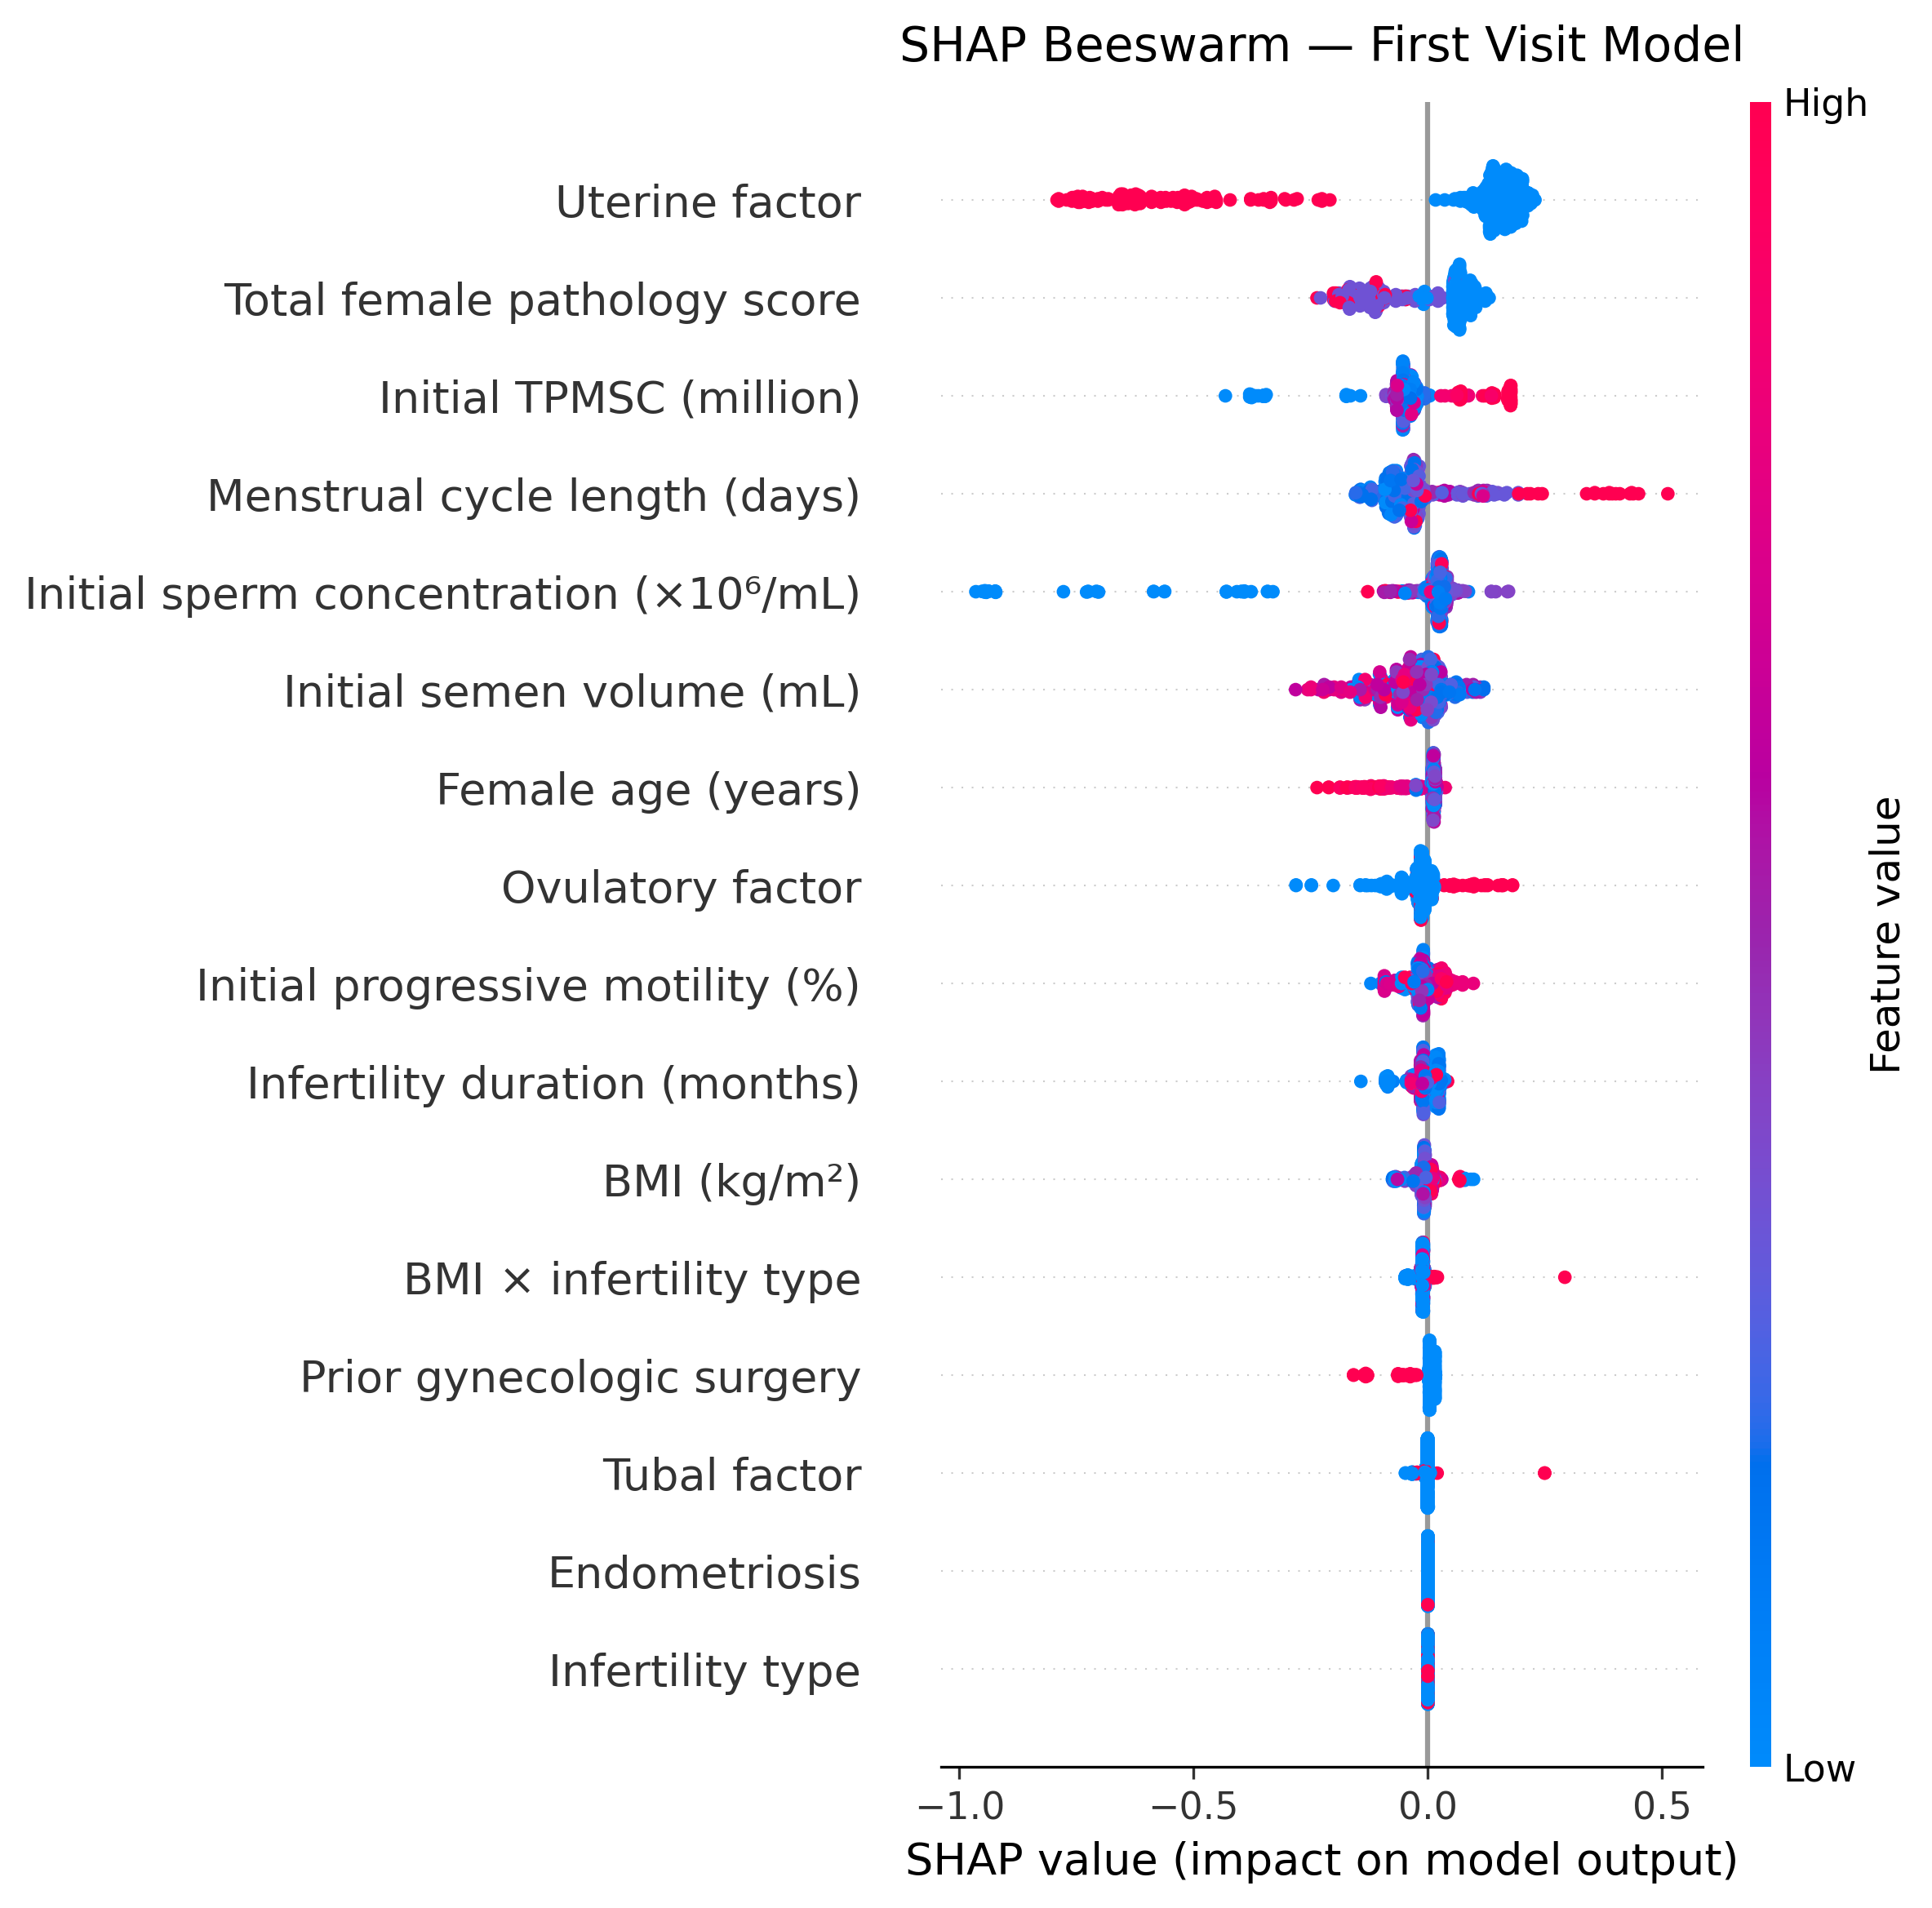

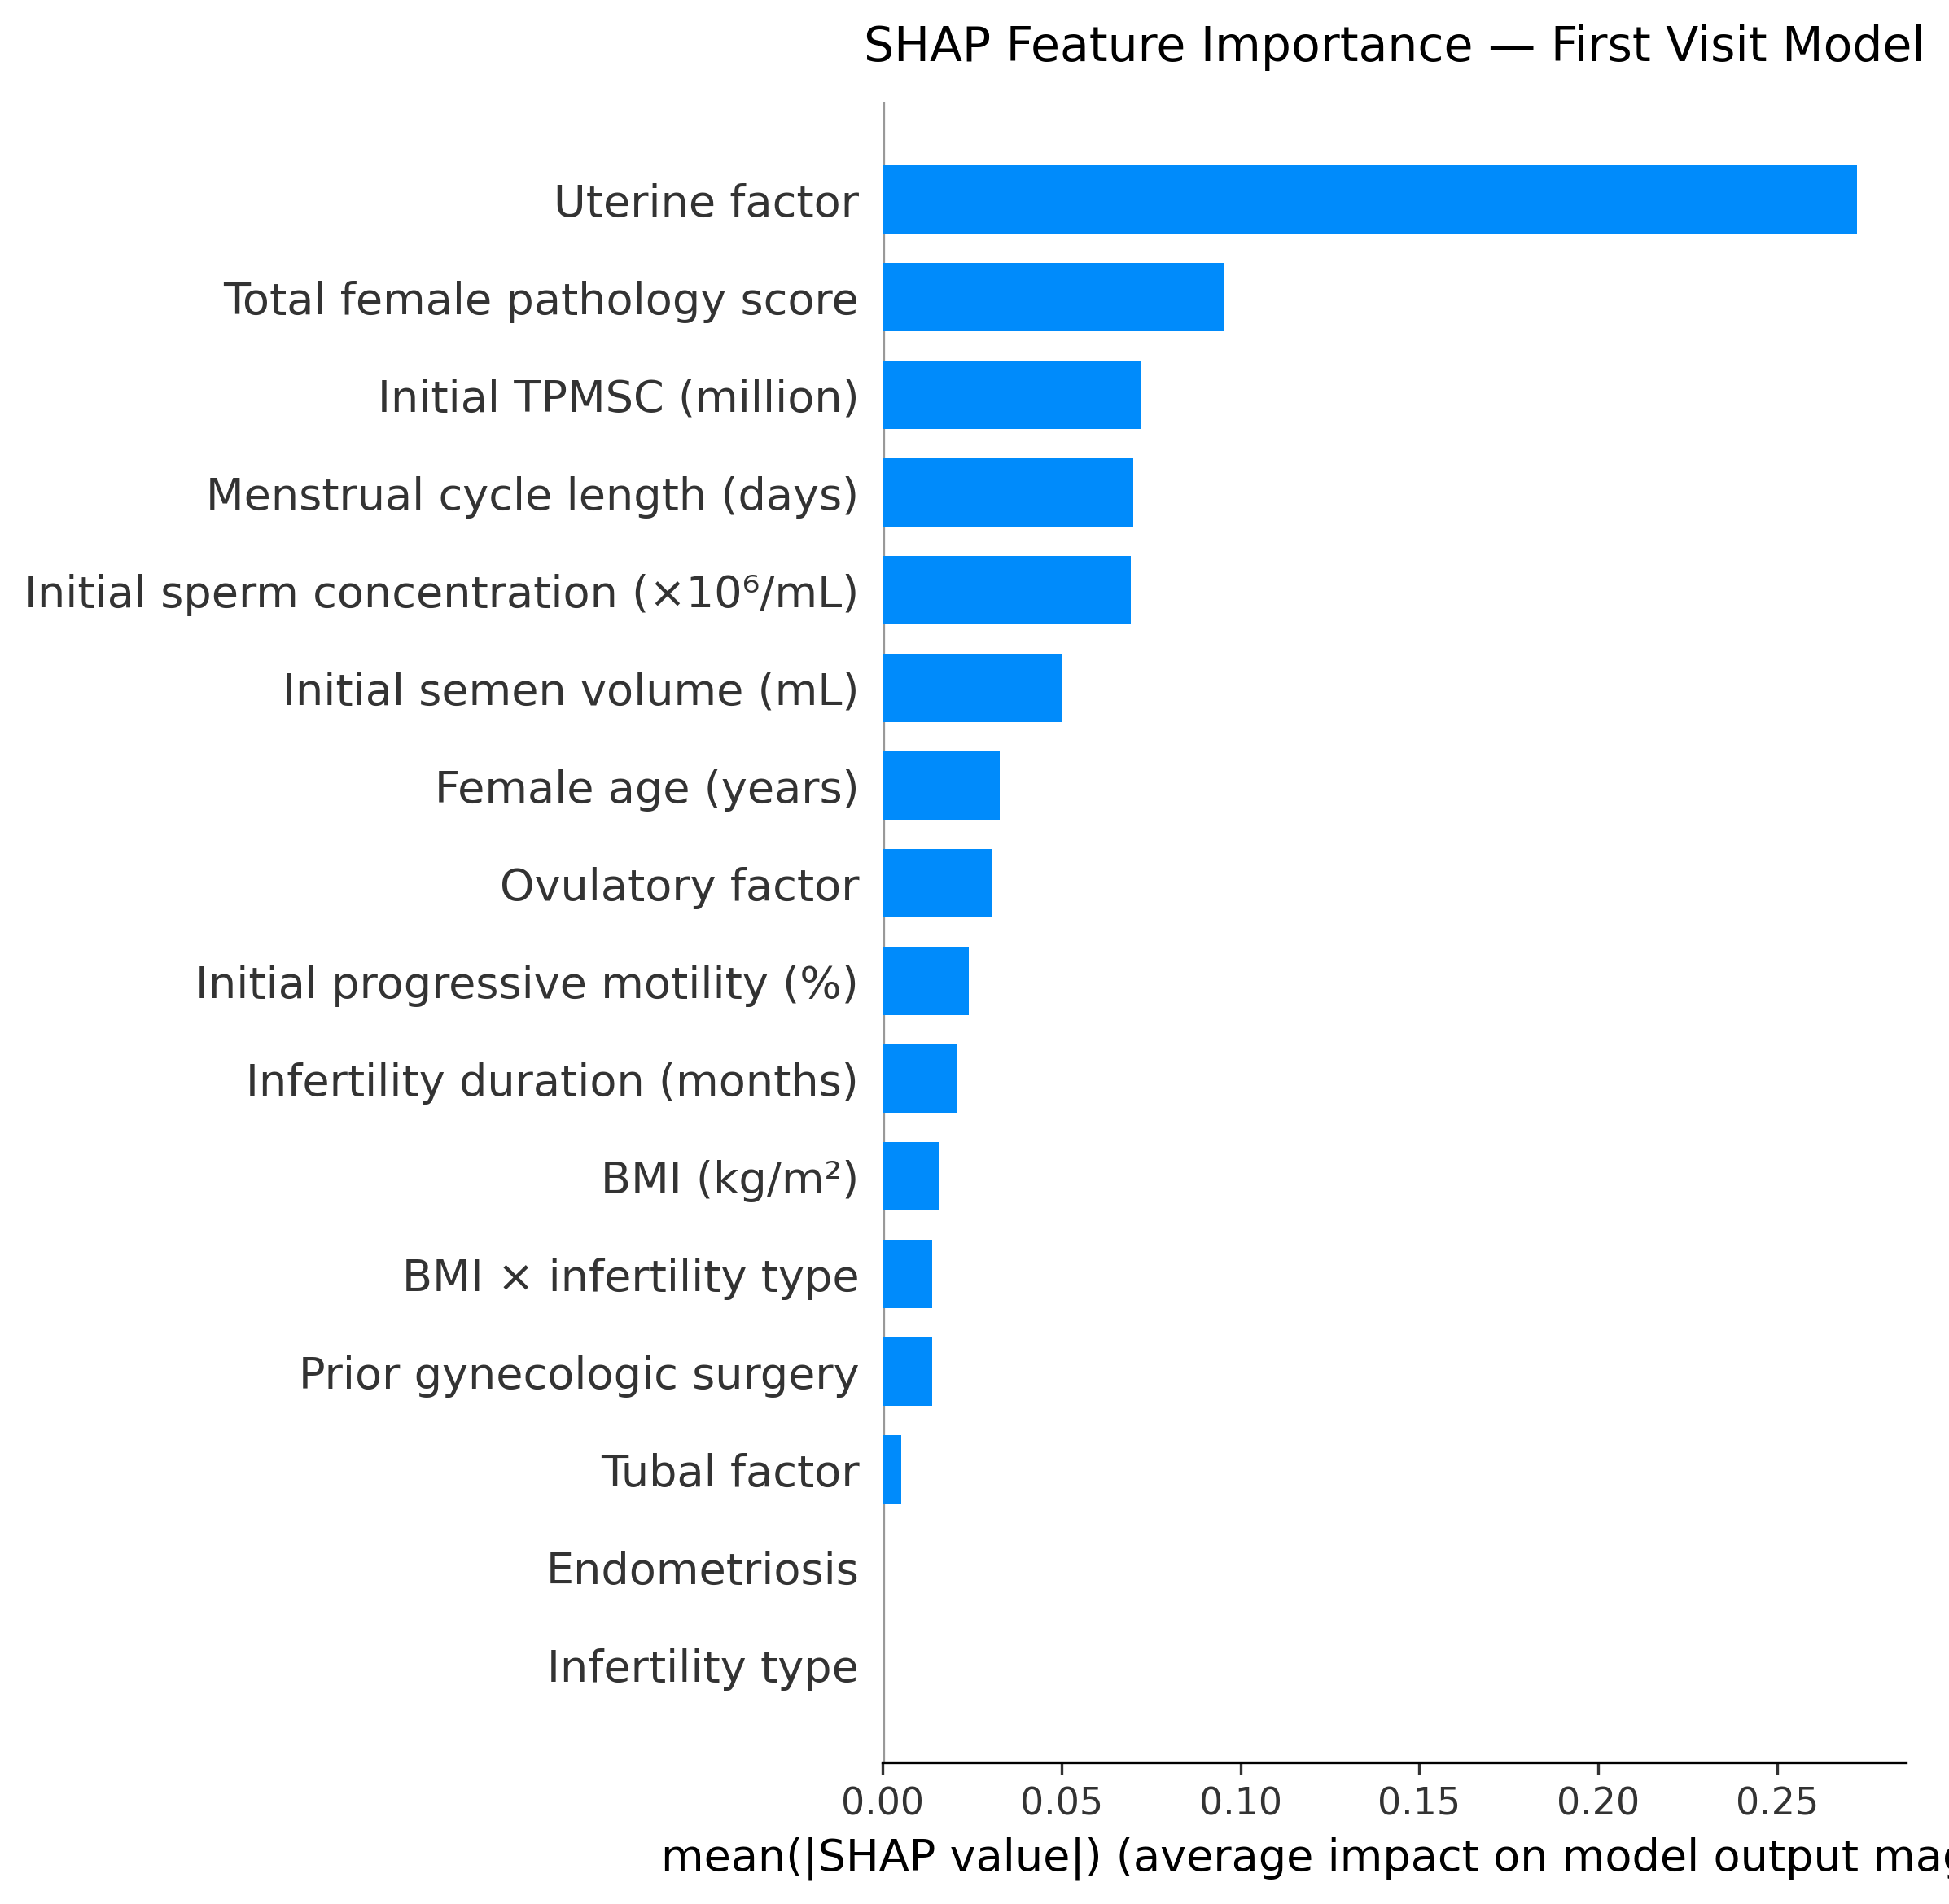

SHAP Feature Importance:
 Rank                       Feature_Display  Mean_Abs_SHAP
    1                        Uterine factor       0.272422
    2          Total female pathology score       0.095273
    3               Initial TPMSC (million)       0.072037
    4         Menstrual cycle length (days)       0.070049
    5 Initial sperm concentration (×10⁶/mL)       0.069381
    6             Initial semen volume (mL)       0.049928
    7                    Female age (years)       0.032749
    8                      Ovulatory factor       0.030531
    9      Initial progressive motility (%)       0.024138
   10         Infertility duration (months)       0.020733
   11                           BMI (kg/m²)       0.015776
   12                BMI × infertility type       0.013726
   13             Prior gynecologic surgery       0.013688
   14                          Tubal factor       0.005039
   15                      Infertility type       0.000000
   16                         E

In [19]:
import shap

DISPLAY_MAP_FV = {
    "Age_Female":                     "Female age (years)",
    "Body_Mass_Index":                "BMI (kg/m²)",
    "Infertility_Type":               "Infertility type",
    "Total_infertile_duration":       "Infertility duration (months)",
    "Menstrual_Interval_Days":        "Menstrual cycle length (days)",
    "Uterine_Factors":                "Uterine factor",
    "Ovulatory_Factors":              "Ovulatory factor",
    "Tubal_Factors":                  "Tubal factor",
    "Endometriosis_Factors":          "Endometriosis",
    "Gynecological_Surgical_History": "Prior gynecologic surgery",
    "Total_Female_Pathology":         "Total female pathology score",
    "First_Volume":                   "Initial semen volume (mL)",
    "First_Count":                    "Initial sperm concentration (×10⁶/mL)",
    "First_Progressive_Motile":       "Initial progressive motility (%)",
    "First_TPMSC":                    "Initial TPMSC (million)",
    "BMI_InfertilityType_Interaction":"BMI × infertility type",
}

display_names_fv = [DISPLAY_MAP_FV.get(f, f) for f in available_fv]

# Retrain on full train set for SHAP (consistent with Postwash model approach)
pos_weight_full_fv = float(
    (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
)
shap_model_fv = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=pos_weight_full_fv,
    **clean_params,
)
shap_model_fv.fit(X_train_fv, y_train)
print(f"FV SHAP model trained on full train set ({len(X_train_fv)} rows, {len(available_fv)} features)")

explainer = shap.TreeExplainer(shap_model_fv)
shap_vals = explainer.shap_values(X_test_fv)

# Beeswarm
plt.figure(figsize=(10, 7), facecolor='white')
shap.summary_plot(shap_vals, X_test_fv,
                  feature_names=display_names_fv,
                  plot_type="dot", show=False, max_display=16)
plt.title("SHAP Beeswarm — First Visit Model", fontsize=14, pad=12)
plt.tight_layout()
path_bee = FIGURE_DIR / "SHAP_Beeswarm_FirstVisit.png"
plt.savefig(path_bee, dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
display(IPImage(str(path_bee)))

# Bar
plt.figure(figsize=(9, 6), facecolor='white')
shap.summary_plot(shap_vals, X_test_fv,
                  feature_names=display_names_fv,
                  plot_type="bar", show=False, max_display=16)
plt.title("SHAP Feature Importance — First Visit Model", fontsize=14, pad=12)
plt.tight_layout()
path_bar = FIGURE_DIR / "SHAP_Bar_FirstVisit.png"
plt.savefig(path_bar, dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
display(IPImage(str(path_bar)))

# SHAP importance table
shap_df = pd.DataFrame({
    "Feature":         available_fv,
    "Feature_Display": display_names_fv,
    "Mean_Abs_SHAP":   np.abs(shap_vals).mean(axis=0)
}).sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)
shap_df["Rank"] = range(1, len(shap_df) + 1)

print("SHAP Feature Importance:")
print(shap_df[["Rank", "Feature_Display", "Mean_Abs_SHAP"]].to_string(index=False))
shap_df.to_csv(REPORT_DIR / "SHAP_Importance_FirstVisit.csv", index=False)

## 15. Decision Curve Analysis (DCA)

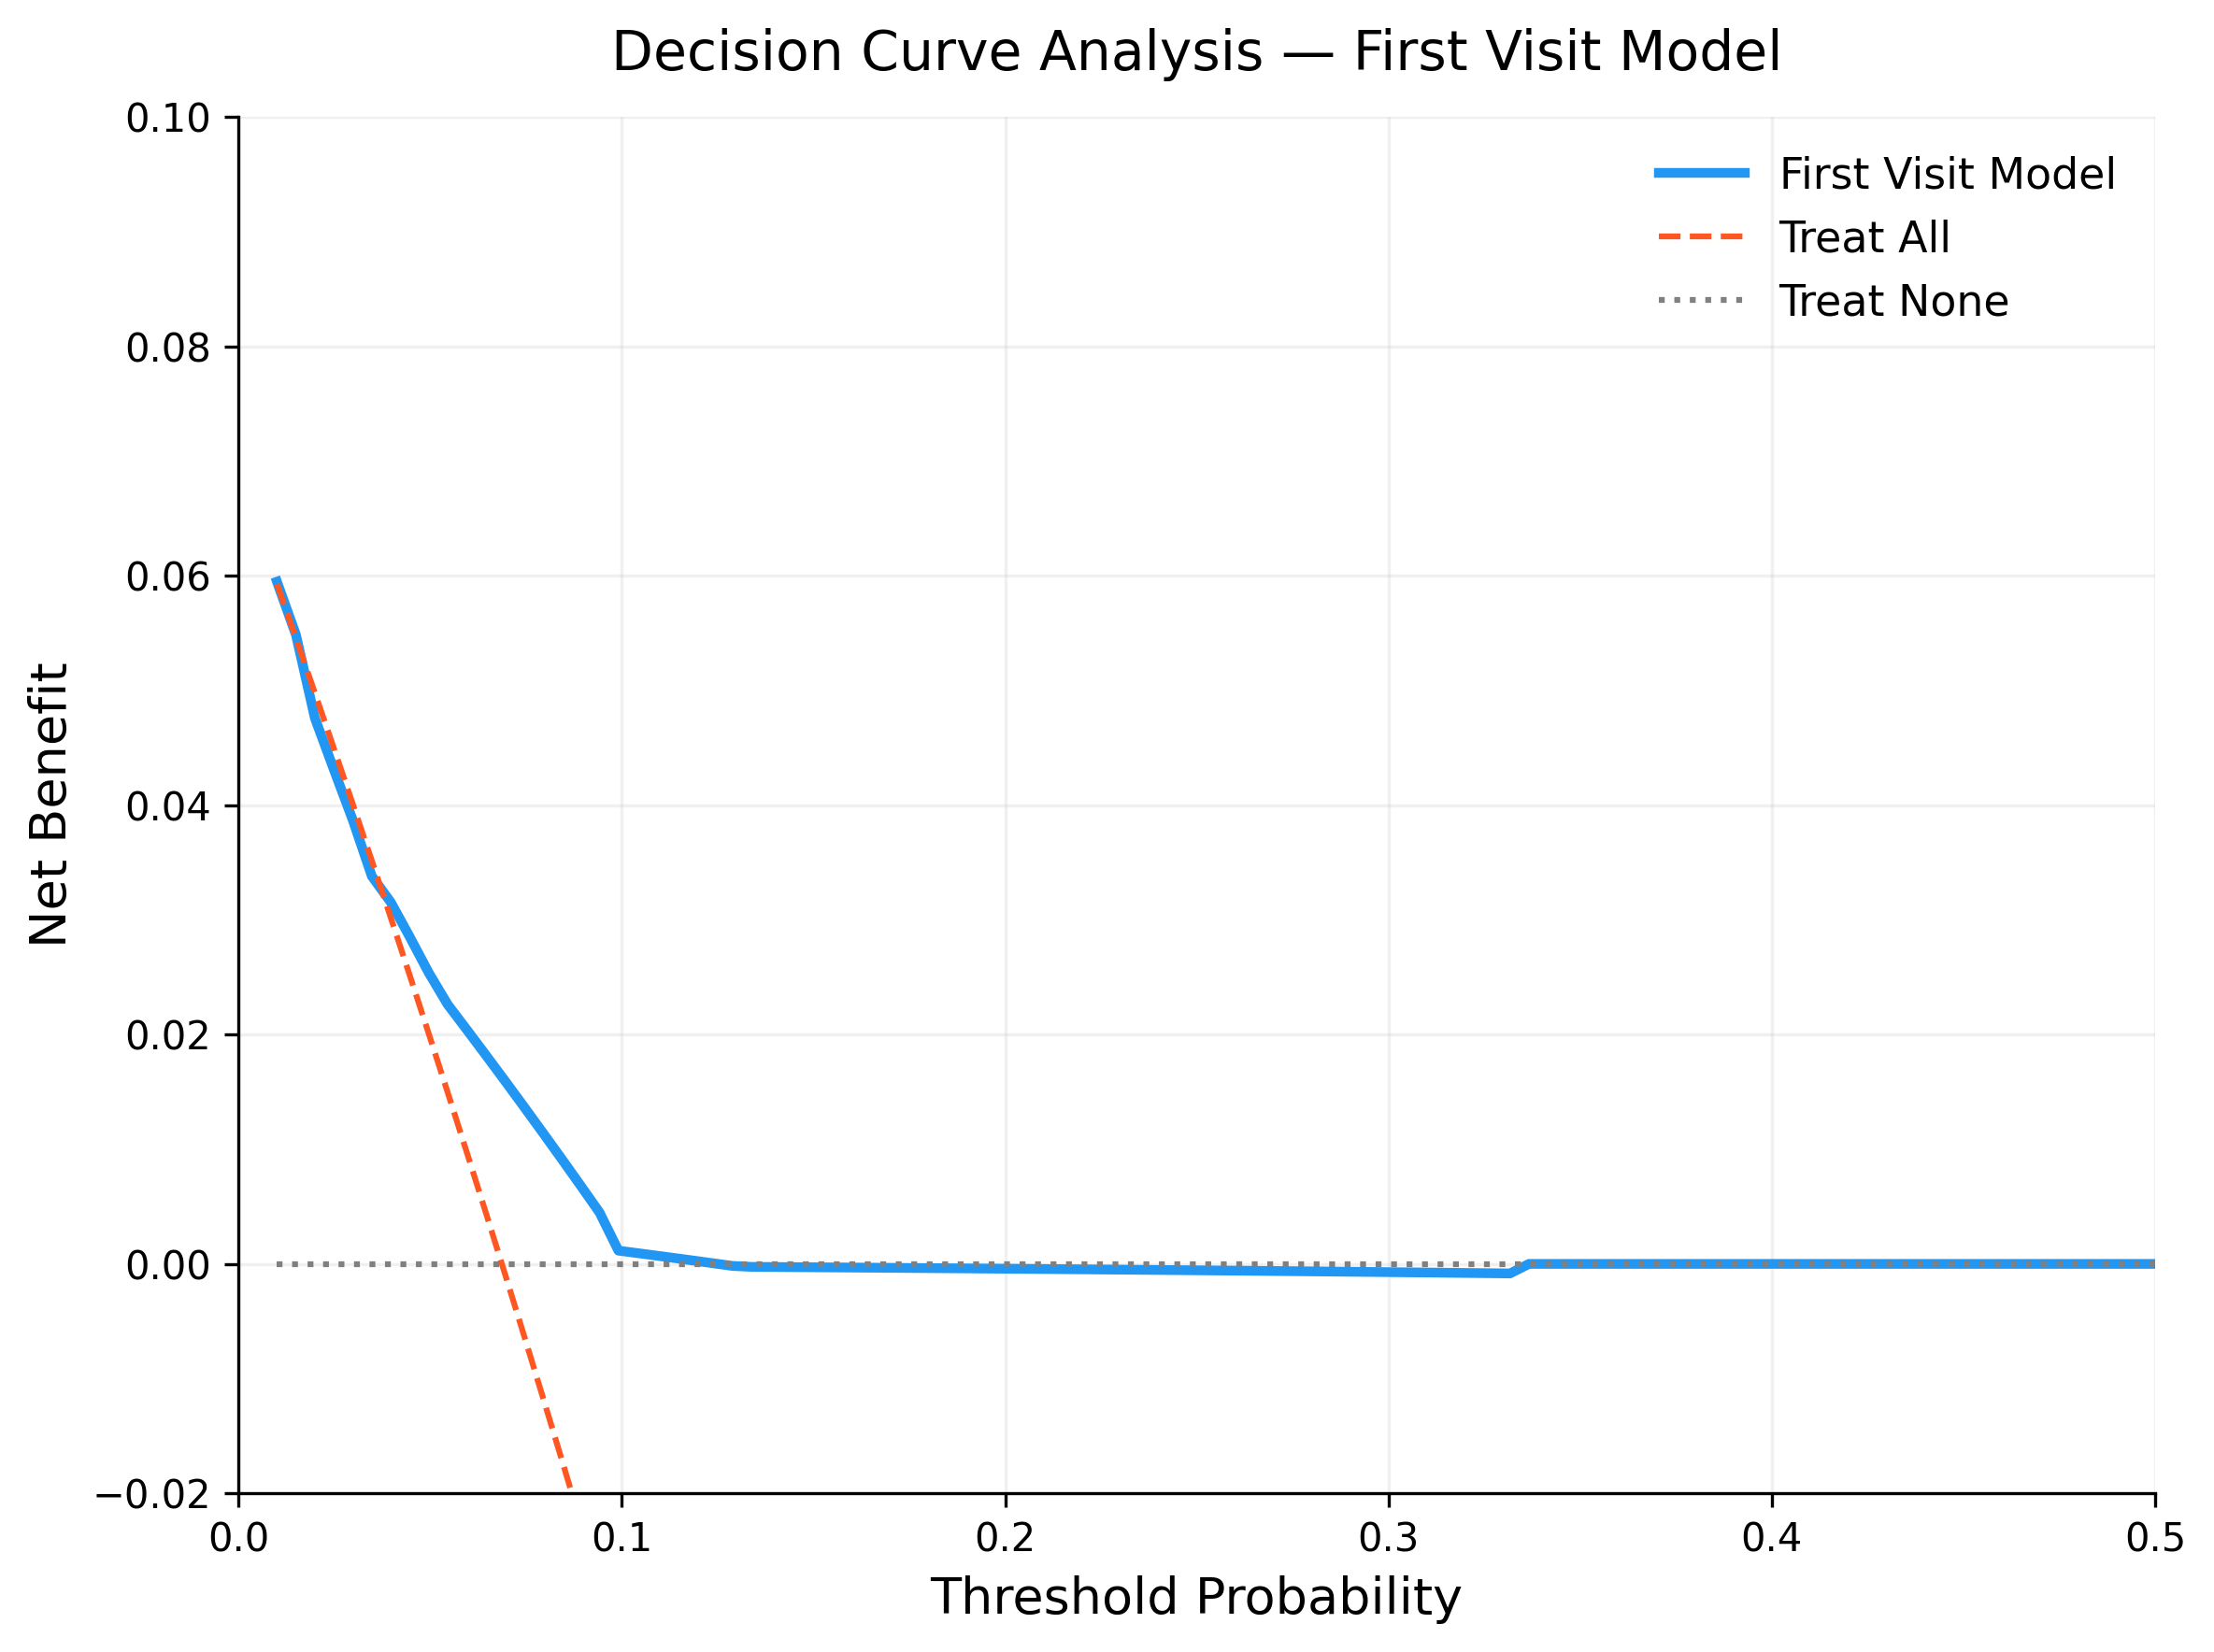

Net benefit at key thresholds:
  threshold=0.039: model=0.0315, treat_all=0.0302
  threshold=0.062: model=0.0182, treat_all=0.0045
  threshold=0.080: model=0.0115, treat_all=-0.0115
  threshold=0.100: model=0.0012, treat_all=-0.0338


In [28]:
thresholds_dca = np.linspace(0.01, 0.50, 100)
y_arr          = np.array(y_test)
n              = len(y_arr)
prevalence     = y_arr.mean()

nb_model, nb_all, nb_none = [], [], []
for thresh in thresholds_dca:
    y_pred_t = (test_probs_cal_fv >= thresh).astype(int)
    tp_t = ((y_pred_t == 1) & (y_arr == 1)).sum()
    fp_t = ((y_pred_t == 1) & (y_arr == 0)).sum()
    nb_model.append((tp_t/n) - (fp_t/n) * (thresh/(1-thresh)))
    nb_all.append(prevalence - (1-prevalence) * (thresh/(1-thresh)))
    nb_none.append(0)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
ax.set_facecolor('white')
ax.plot(thresholds_dca, nb_model, color='#2196F3', linewidth=2.5,
        label='First Visit Model')
ax.plot(thresholds_dca, nb_all,   color='#FF5722', linewidth=1.5,
        linestyle='--', label='Treat All')
ax.plot(thresholds_dca, nb_none,  color='gray',    linewidth=1.5,
        linestyle=':', label='Treat None')
ax.set_xlabel('Threshold Probability', fontsize=13)
ax.set_ylabel('Net Benefit', fontsize=13)
ax.set_title('Decision Curve Analysis — First Visit Model', fontsize=14, pad=12)
ax.set_xlim([0, 0.50])
ax.set_ylim([-0.02, 0.10])
ax.legend(frameon=False, fontsize=11)
ax.grid(alpha=0.18)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
path_dca = FIGURE_DIR / "DCA_FirstVisit.png"
plt.savefig(path_dca, dpi=300, bbox_inches='tight', facecolor='white')
plt.close()

# แสดงผลใน notebook
display(IPImage(str(path_dca)))

print("Net benefit at key thresholds:")
for thresh in [0.039, 0.062, 0.080, 0.10]:
    idx = np.argmin(np.abs(thresholds_dca - thresh))
    print(f"  threshold={thresh:.3f}: model={nb_model[idx]:.4f}, "
          f"treat_all={nb_all[idx]:.4f}")